In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pa_gs = pd.read_csv('data/pa_data.csv')

starting_mean = pa_gs[pa_gs['year'].between(1955, 1960)]
ending_mean = pa_gs[pa_gs['year'].between(2020, 2025)]

starting_mean = starting_mean[['year', 'latitude', 'longitude', 'station_name', 'growing_season_length']]
ending_mean = ending_mean[['year', 'latitude', 'longitude', 'station_name', 'growing_season_length']]

starting_mean = starting_mean.groupby('station_name').agg(['mean'])
ending_mean = ending_mean.groupby('station_name').agg(['mean'])

starting_mean.columns = ['_'.join(col).strip() for col in starting_mean.columns.values]
ending_mean.columns = ['_'.join(col).strip() for col in ending_mean.columns.values]

starting_mean = starting_mean.reset_index()
starting_mean.columns = ['station_name', 'year', 'latitude', 'longitude', 'growing_season_length']
ending_mean = ending_mean.reset_index()
ending_mean.columns = ['station_name', 'year', 'latitude', 'longitude', 'growing_season_length']

lon_start = starting_mean['longitude']
lat_start = starting_mean['latitude']
lat_end = ending_mean['latitude']
lon_end = ending_mean['longitude']
var_start = starting_mean['growing_season_length']
var_end = ending_mean['growing_season_length']

OK_start = OrdinaryKriging(x=lon_start, y=lat_start, z=var_start, variogram_model='exponential', coordinates_type='geographic')
grid_lat_start = np.arange(min(lat_start), max(lat_start), 0.3)
grid_lon_start = np.arange(min(lon_start), max(lon_start), 0.3)
zstar_start, ss_start = OK_start.execute('grid', grid_lon_start, grid_lat_start)

OK_end = OrdinaryKriging(x=lon_end, y=lat_end, z=var_end, variogram_model='exponential', coordinates_type='geographic')
grid_lat_end = np.arange(min(lat_end), max(lat_end), 0.3)
grid_lon_end = np.arange(min(lon_end), max(lon_end), 0.3)
zstar_end, ss_end = OK_end.execute('grid', grid_lon_end, grid_lat_end)

zstar_diff = zstar_end - zstar_start

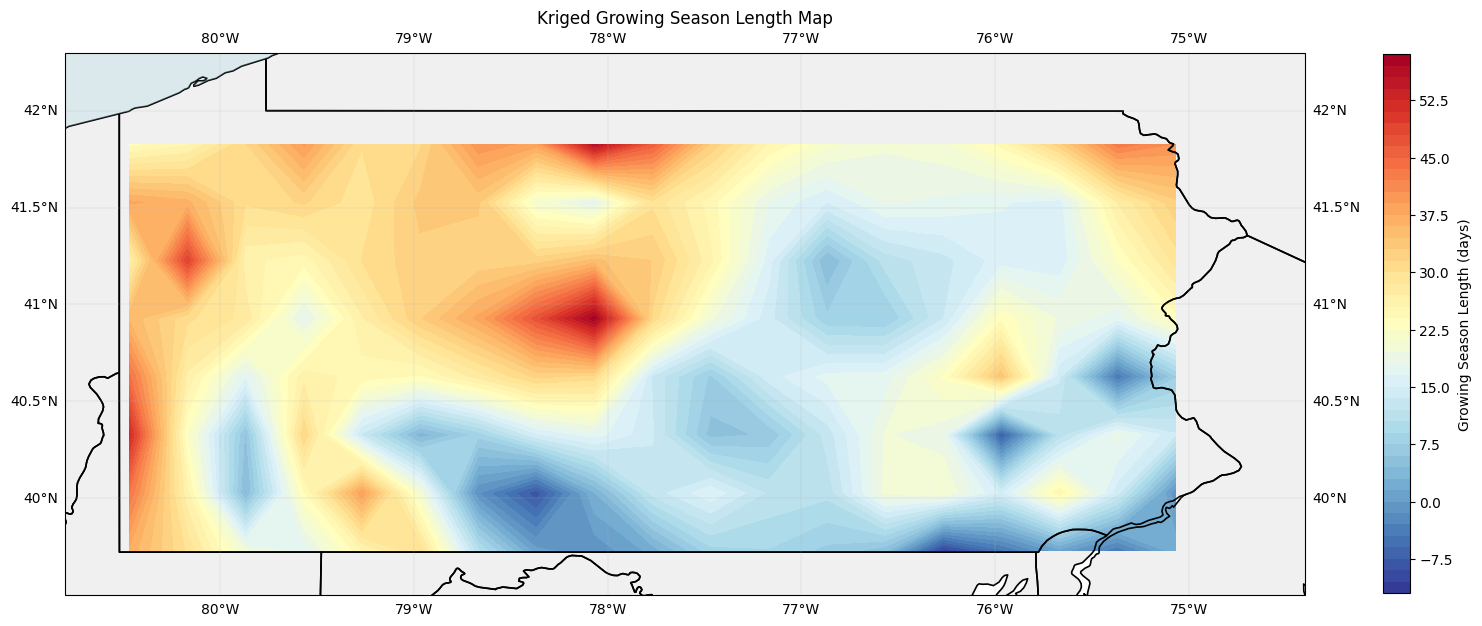

In [20]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_end, grid_lat_end, zstar_diff, levels=50 , cmap='RdYlBu_r')
plt.colorbar(label='Growing Season Length (days)', shrink = 0.7)
plt.title('Kriged Growing Season Length Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.show()

In [21]:
import statistics

In [104]:
# calculate the variance at each station and interpolate between
station_names = pa_gs['station_name'].unique().tolist()
station_dict = {name: pa_gs.loc[pa_gs['station_name'] == name].reset_index().drop(['index', 'station_id'], axis=1) for name in station_names}

var_dict = {name: statistics.variance(station_dict[name]['growing_season_length']) for name in station_names}

var_df = pd.DataFrame({
    'variance': var_dict,
    'latitude': [pa_gs.loc[pa_gs['station_name'] == name, 'latitude'].iloc[0] for name in station_names],
    'longitude': [pa_gs.loc[pa_gs['station_name'] == name, 'longitude'].iloc[0] for name in station_names]
}, index=station_names)

lat_var = var_df['latitude']
lon_var = var_df['longitude']
var_variance = var_df['variance']
var_df

,variance,latitude,longitude
ACMETONIA LOCK 3,241.824176,40.5361,-79.8153
ALLENTOWN GAS COMPANY,199.317073,40.6000,-75.4667
ALTOONA HORSESHOE CURV,418.392606,40.5000,-78.4833
ALTOONA 3 W,282.380471,40.4950,-78.4667
ALVIN R BUSH DAM,32.000000,41.3578,-77.9264
...,...,...,...
ERIE INTL AP,406.833939,42.0803,-80.1822
PITTSBURGH WSO CITY,234.546099,40.4500,-80.0000
YORK AP,324.920635,39.9194,-76.8769
NE PHILA AP,294.696065,40.0789,-75.0133


In [66]:
OK_var = OrdinaryKriging(x=lon_var, y=lat_var, z=var_variance, variogram_model='exponential', coordinates_type='geographic')
grid_lat_var = np.arange(min(lat_var), max(lat_var), 0.3)
grid_lon_var = np.arange(min(lon_var), max(lon_var), 0.3)
zstar_var, ss_var = OK_var.execute('grid', grid_lon_var, grid_lat_var)

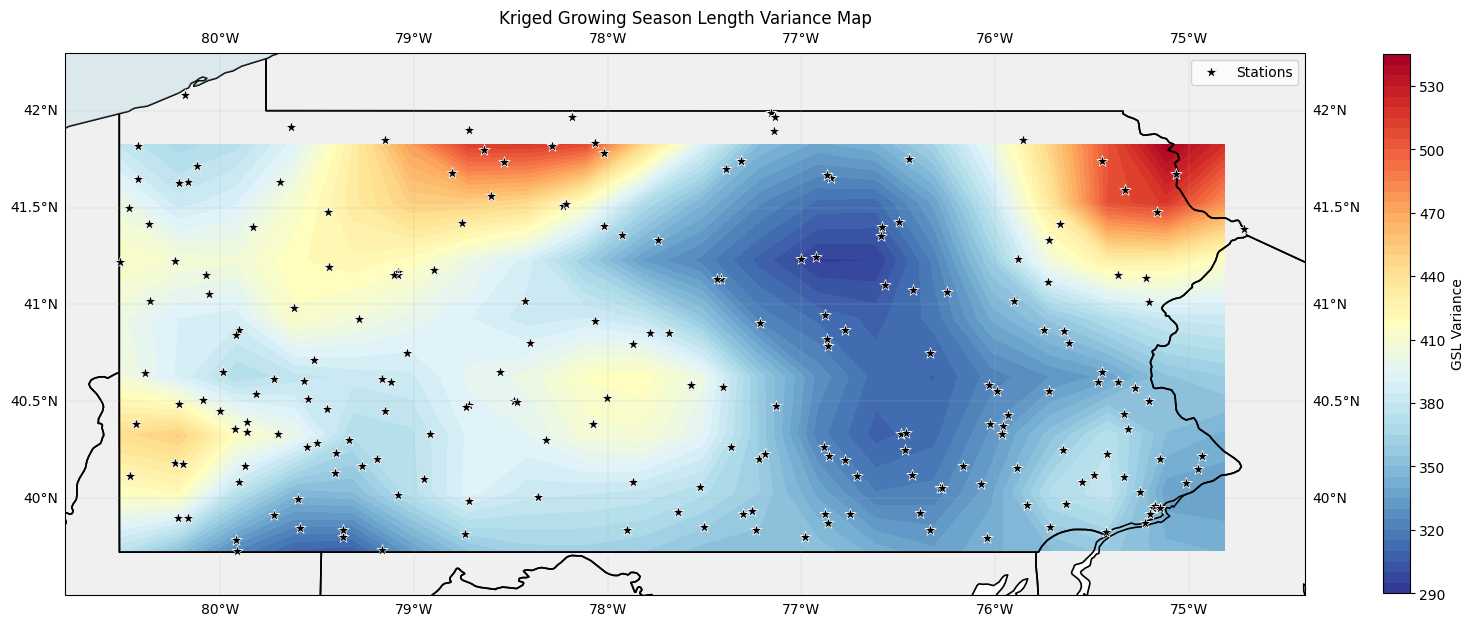

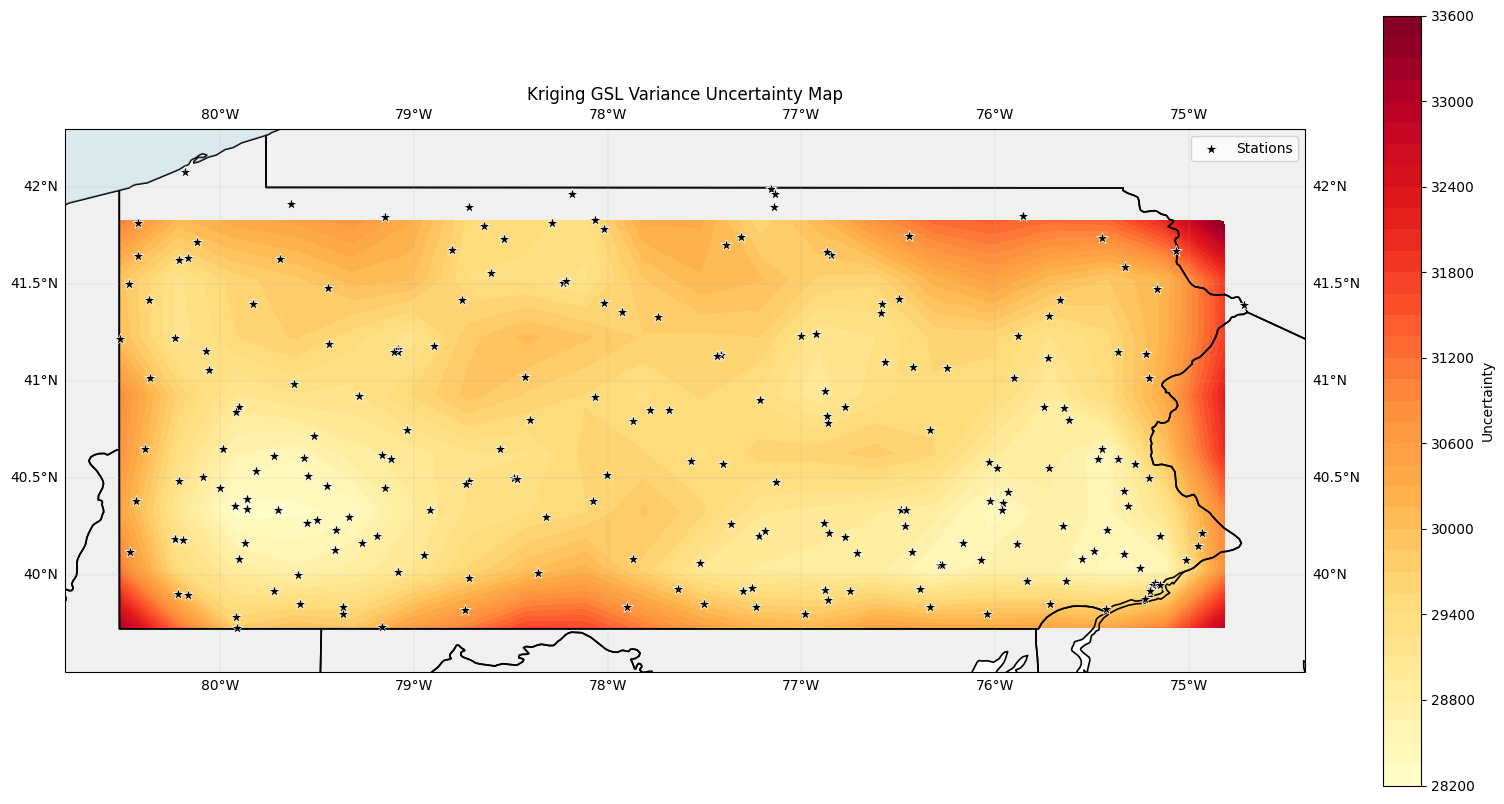

In [100]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_var, grid_lat_var, zstar_var, levels=50 , cmap='RdYlBu_r')
plt.colorbar(label='GSL Variance', shrink = 0.7)
plt.scatter(lon_var, lat_var, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriged Growing Season Length Variance Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()


plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
plt.contourf(grid_lon_var, grid_lat_var, ss_var, levels=50 , cmap='YlOrRd')
plt.colorbar(label='Uncertainty')
plt.scatter(lon_var, lat_var, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
plt.title('Kriging GSL Variance Uncertainty Map')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.legend()
plt.show()

In [73]:
def calculate_variance_by_year_interval(pa_gs, start_year=None, end_year=None):
    """
    Calculate variance of growing_season_length for each station within a year interval.
    
    Parameters:
    pa_gs: DataFrame with 'station_name', 'growing_season_length', 'latitude', 'longitude', and 'year' columns
    start_year: int, optional - minimum year (inclusive). If None, uses minimum year in data
    end_year: int, optional - maximum year (inclusive). If None, uses maximum year in data
    
    Returns:
    var_df: DataFrame with variance, latitude, and longitude for each station
    """
    
    # Subset by year interval
    if start_year is None:
        start_year = pa_gs['year'].min()
    if end_year is None:
        end_year = pa_gs['year'].max()
    
    pa_gs_subset = pa_gs[(pa_gs['year'].between(start_year, end_year))].copy()
    
    # Create station dictionary
    station_names = pa_gs_subset['station_name'].unique().tolist()
    station_dict = {
        name: pa_gs_subset.loc[pa_gs_subset['station_name'] == name].reset_index().drop(['index', 'station_id'], axis=1) 
        for name in station_names
    }
    
   # Calculate variance only for stations with at least 2 data points
    var_dict = {}
    valid_stations = []
    
    for name in station_names:
        gsl_data = station_dict[name]['growing_season_length']
        if len(gsl_data) >= 2:  # Only calculate if 2+ data points
            var_dict[name] = statistics.variance(gsl_data)
            valid_stations.append(name)
    
    # Create results DataFrame
    var_df = pd.DataFrame({
        'variance': var_dict,
        'latitude': [pa_gs_subset.loc[pa_gs_subset['station_name'] == name, 'latitude'].iloc[0] for name in station_names],
        'longitude': [pa_gs_subset.loc[pa_gs_subset['station_name'] == name, 'longitude'].iloc[0] for name in station_names]
    }, index=station_names)
    
    return var_df

In [90]:
var_df_80_23 = calculate_variance_by_year_interval(pa_gs, 1980, 2023)
var_df_80_23

,variance,latitude,longitude
ACMETONIA LOCK 3,261.666667,40.5361,-79.8153
ALTOONA 3 W,258.380488,40.4950,-78.4667
BAKERSTOWN 3 WNW,278.500000,40.6500,-79.9833
BELTZVILLE DAM,184.666667,40.8619,-75.6428
BIGLERVILLE,552.046512,39.9347,-77.2547
...,...,...,...
WILLOW GROVE NAS,218.045161,40.2000,-75.1500
ERIE INTL AP,270.131078,42.0803,-80.1822
YORK AP,347.718462,39.9194,-76.8769
NE PHILA AP,331.904334,40.0789,-75.0133


In [123]:
def OK_plotter(df, variable, var_name):
    lat = df['latitude']
    lon = df['longitude']
    var = df[variable]

    OK = OrdinaryKriging(x=lon, y=lat, z=var, variogram_model='exponential', coordinates_type='geographic')
    grid_lat = np.arange(min(lat), max(lat), 0.3)
    grid_lon = np.arange(min(lon), max(lon), 0.3)
    zstar, ss = OK.execute('grid', grid_lon, grid_lat)

    plt.figure(figsize=(20,10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-80.8, -74.4, 39.5, 42.3])
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
    ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
    plt.contourf(grid_lon, grid_lat, zstar, levels=40 , cmap='RdYlBu_r')
    plt.colorbar(label=f'{variable}', shrink = 0.7)
    plt.scatter(lon_var, lat_var, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
    plt.title(f'Kriged {var_name} Map')
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    plt.legend()
    plt.show()
                
    
    plt.figure(figsize=(20,10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-80.8, -74.4, 39.5, 42.3])
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
    ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
    ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
    plt.contourf(grid_lon, grid_lat, ss, levels=40 , cmap='YlOrRd')
    plt.colorbar(label='Uncertainty')
    plt.scatter(lon, lat, color='black', s=75, marker='*', edgecolor = 'white', linewidth=0.5, label='Stations', zorder=5)
    plt.title(f'Kriging {var_name} Uncertainty Map')
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    plt.legend()
    plt.show()

def remove_nulls_simple(data_set, columns, ignore_idx):
    #takes the name of a data set and the selected columns and returns a cleaned data set, dropping only rows
    #where the inputted columns have null values

    data_set_cleaned = data_set.dropna(subset=columns, ignore_index=ignore_idx)
    return data_set_cleaned[columns]

count     146.000000
mean      336.471790
std       193.830680
min        36.250000
25%       219.601923
50%       274.929429
75%       383.967106
max      1482.027778
Name: variance, dtype: float64


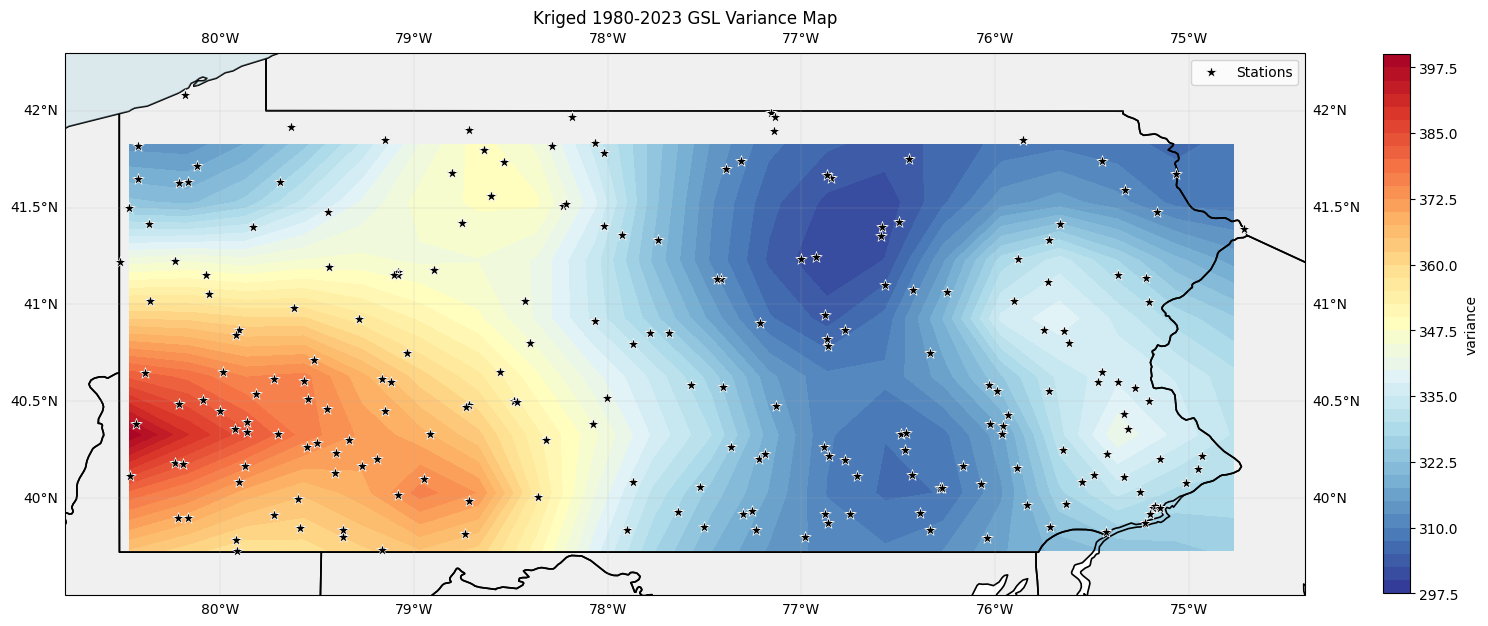

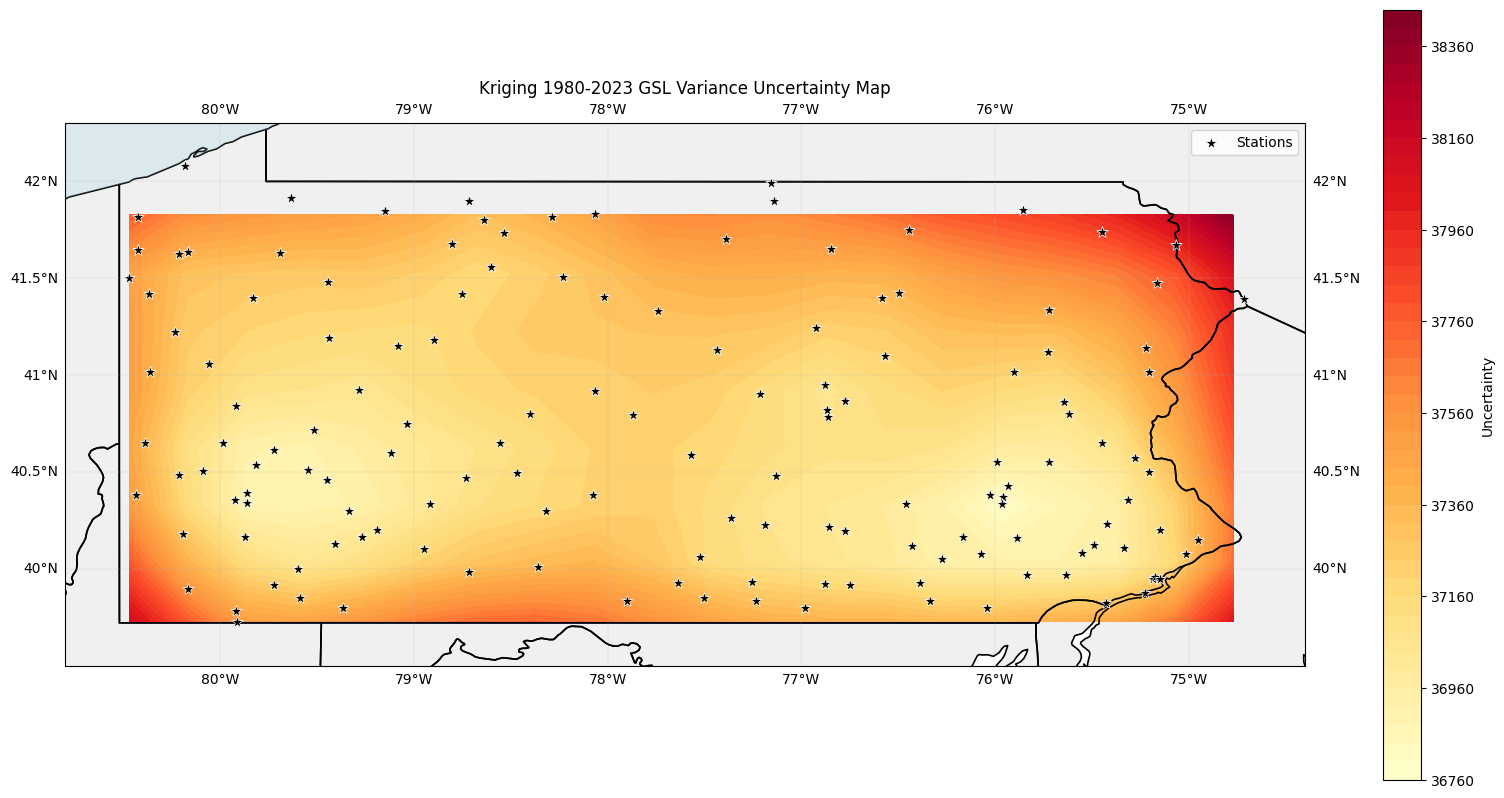

In [174]:
var_df_80_23_cleaned = remove_nulls_simple(var_df_80_23, ['variance', 'latitude', 'longitude'], False)

var_df_80_23_cleaned = var_df_80_23_cleaned.drop('HUNTINGDON')
print(var_df_80_23_cleaned['variance'].describe())

OK_plotter(var_df_80_23_cleaned, 'variance', '1980-2023 GSL Variance')

In [182]:
var_df_80_95 = calculate_variance_by_year_interval(pa_gs, 1980, 1995)
var_df_95_10 = calculate_variance_by_year_interval(pa_gs, 1995, 2010)
var_df_10_23 = calculate_variance_by_year_interval(pa_gs, 2010, 2023)

In [183]:
var_df_80_95_cleaned = remove_nulls_simple(var_df_80_95, ['variance', 'latitude', 'longitude'], False)
var_df_95_10_cleaned = remove_nulls_simple(var_df_95_10, ['variance', 'latitude', 'longitude'], False)
var_df_10_23_cleaned = remove_nulls_simple(var_df_10_23, ['variance', 'latitude', 'longitude'], False)

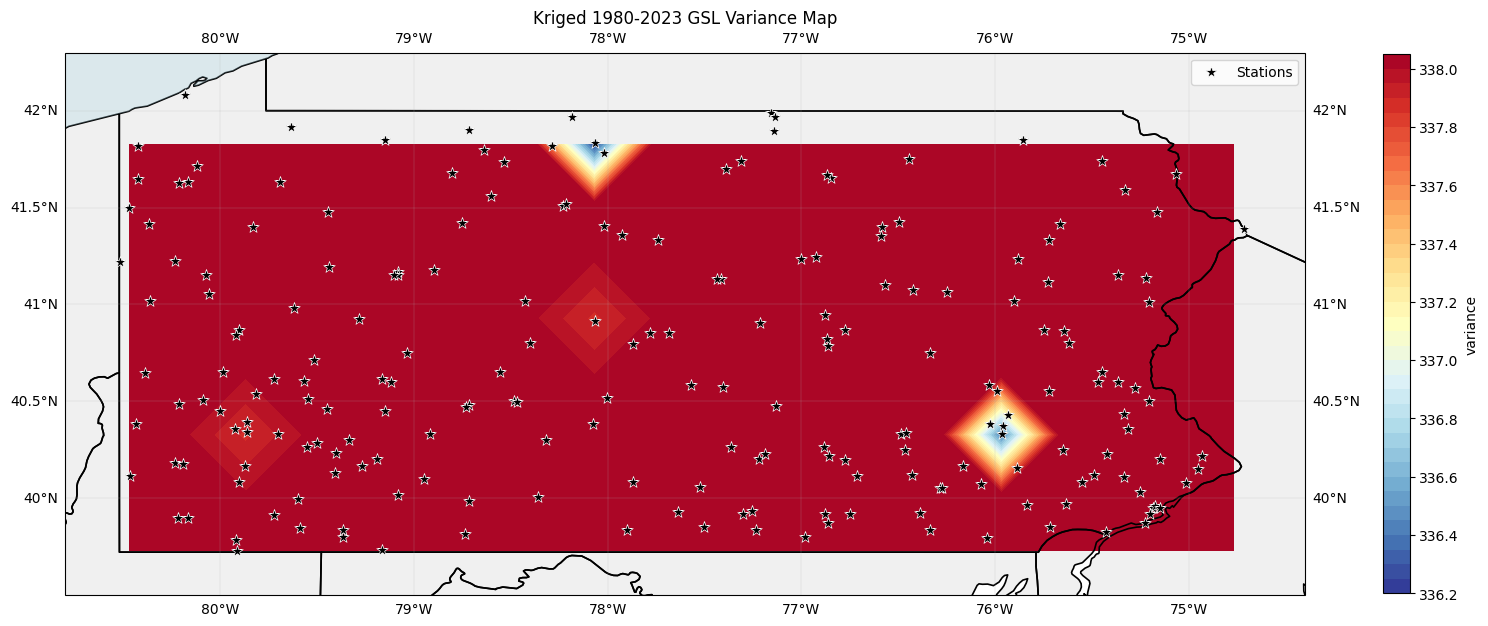

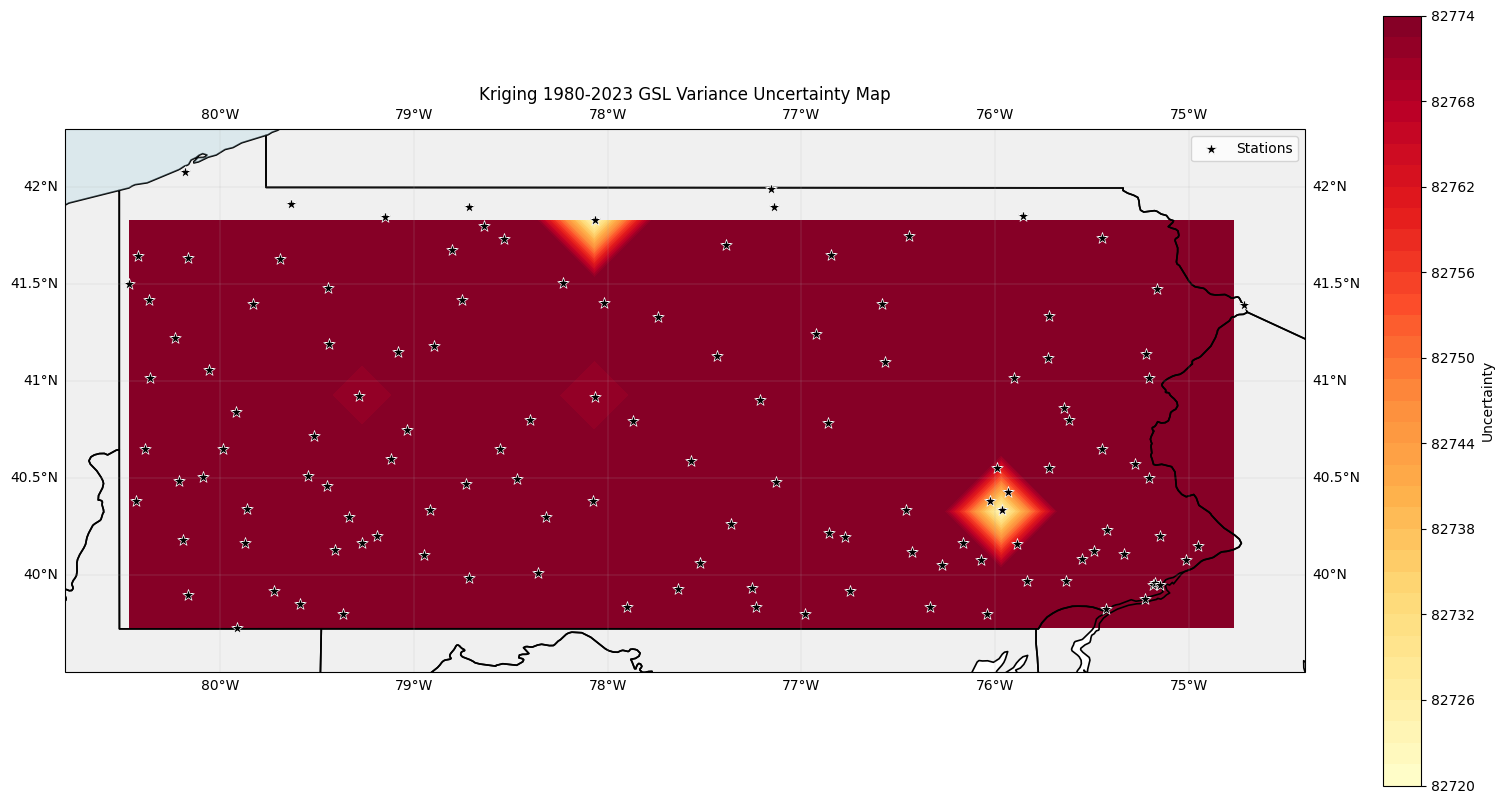

In [184]:
OK_plotter(var_df_80_95_cleaned, 'variance', '1980-2023 GSL Variance')

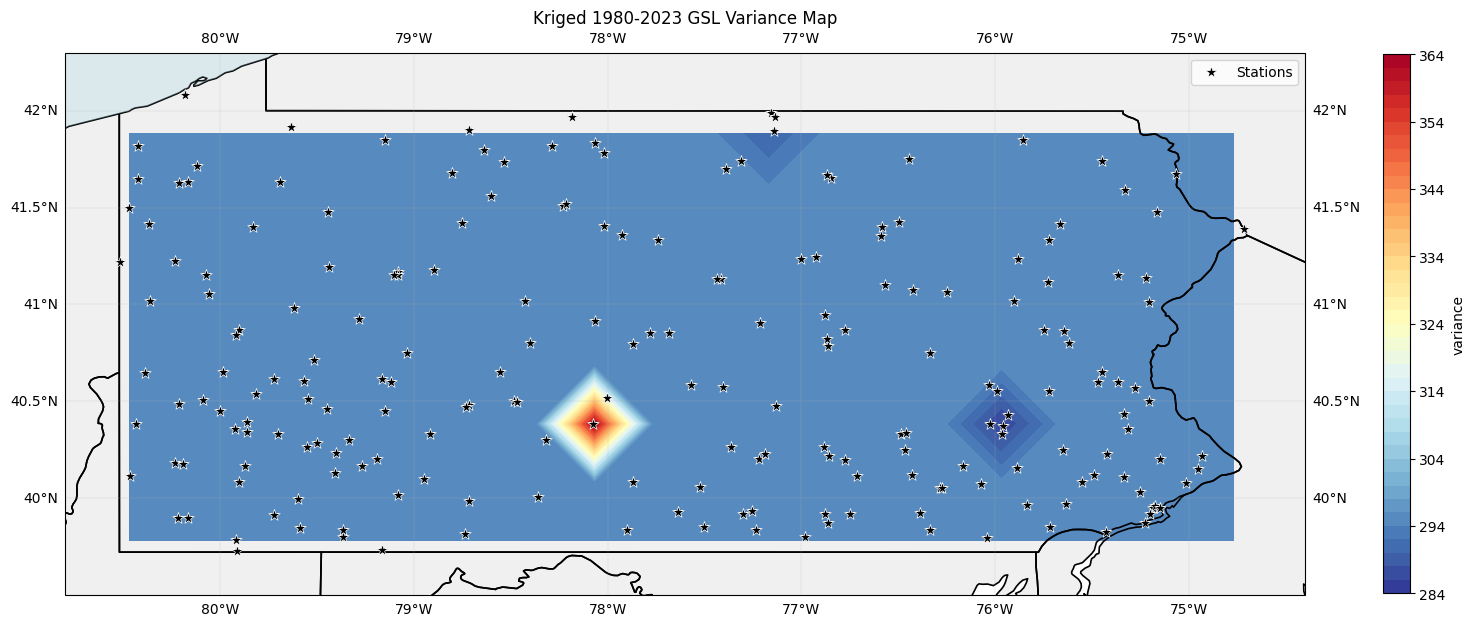

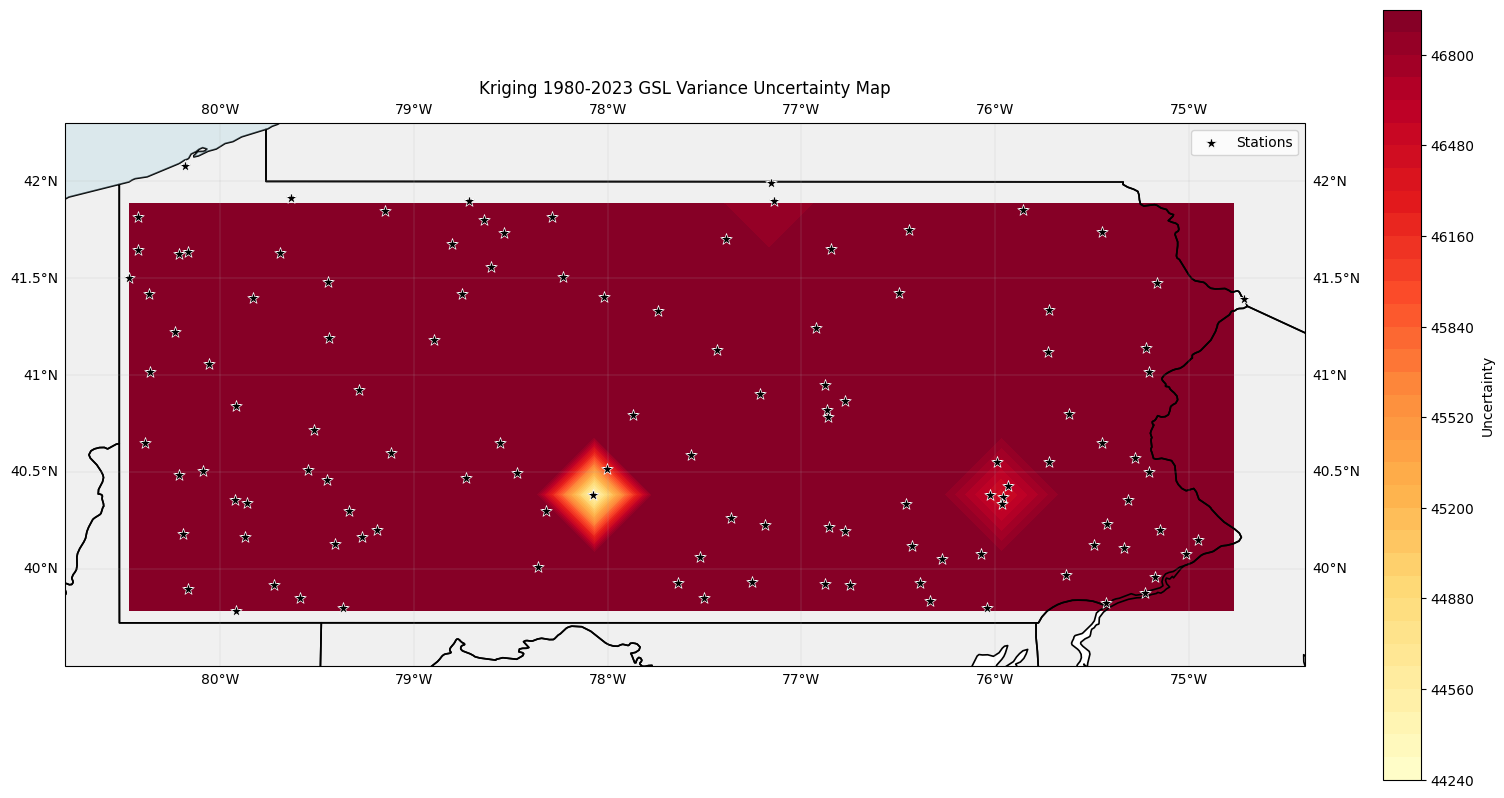

In [185]:
OK_plotter(var_df_95_10_cleaned, 'variance', '1980-2023 GSL Variance')

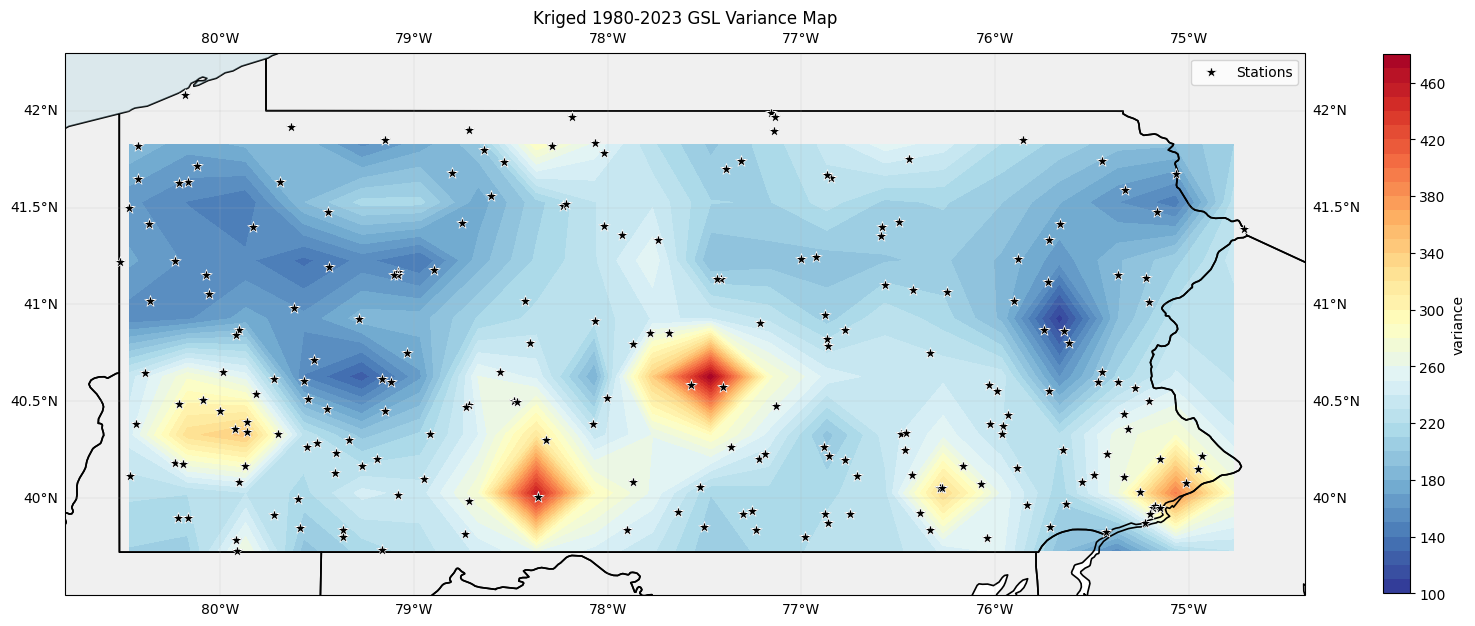

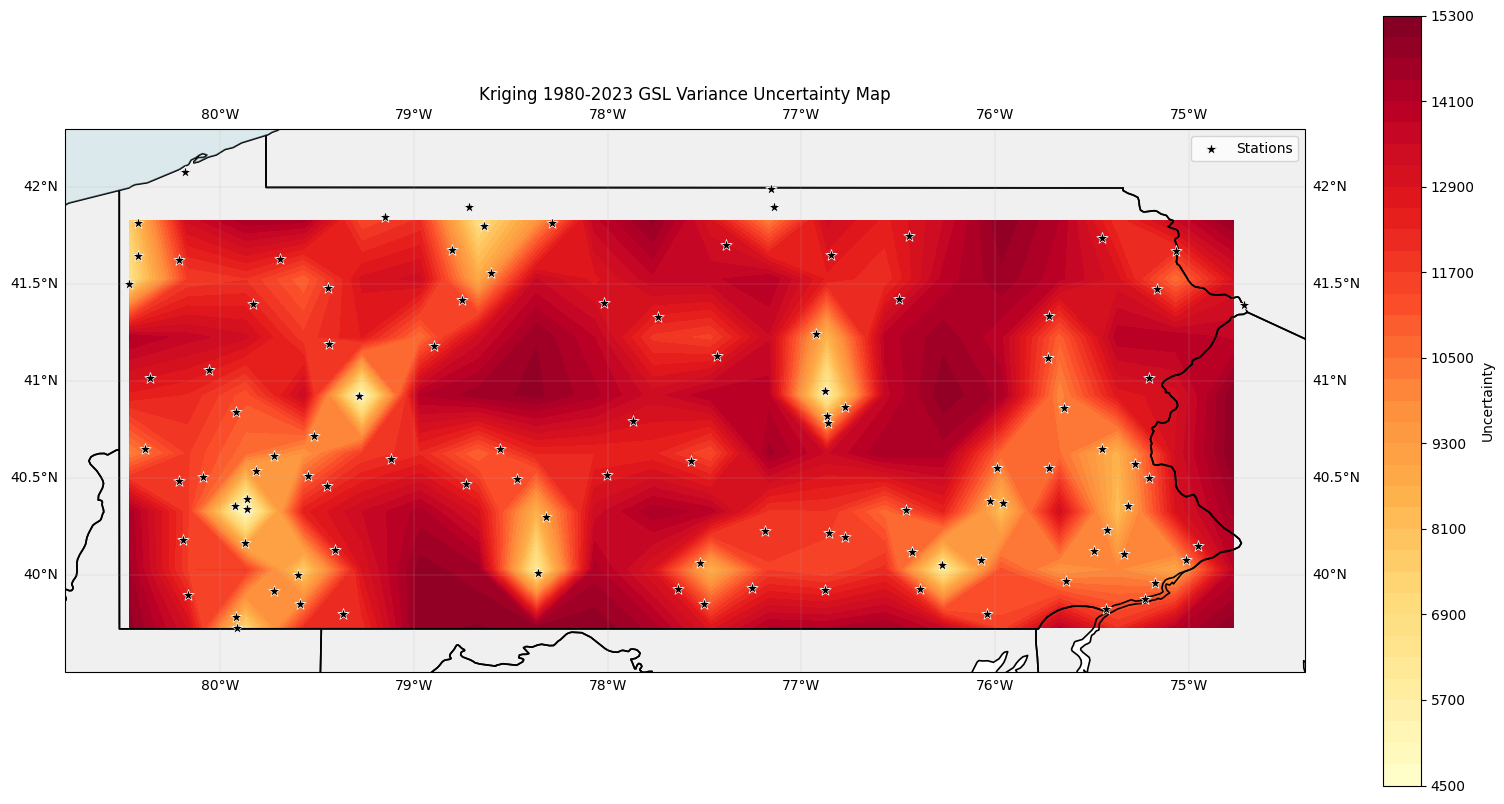

In [186]:
OK_plotter(var_df_10_23_cleaned, 'variance', '1980-2023 GSL Variance')